# Data Breakdown 


In [108]:
# Libraries import
import pandas as pd 
import numpy as np
import matplotlib.pyplot as py
import seaborn as sns


# Overall view of the data set
file = "Engineering_graduate_salary.csv"
df = pd.read_csv(file)
df.head(100)

,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,...,-1,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,...,-1,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,-1,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,...,-1,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,...,-1,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1251678,m,1990-12-23,77.00,cbse,2007,78.00,cbse,6884,2,...,-1,-1,-1,-1,-1.4517,-0.6201,-1.8344,-0.10760,0.6721,100000
96,920550,f,1993-08-10,75.60,cbse,2010,83.20,cbse,55,2,...,-1,-1,-1,-1,1.2772,1.5444,1.8543,1.03330,1.2470,160000
97,134985,m,1983-10-23,75.00,wbbse,2002,61.70,wbchse,1424,2,...,-1,-1,-1,-1,-0.4173,-0.1232,-0.0537,-0.40780,-0.1295,310000
98,1062180,m,1991-06-28,74.00,cbse,2009,66.80,cbse,13801,2,...,-1,-1,-1,-1,-0.5899,-2.2851,-0.7585,0.01920,-2.5853,80000


# Idea 1: School Boards vs. College Majors
- **Main Goal:** If students from certain school boards (*CBSE* or *ICSE*) score better and if the students tend to choose specific engineering branches.

- **Data Cleanup (Transformation):**
1) **Text Errors:** The `12 board` column has messy text, for example some typed `cbse`, some are `CBSE` or `central board`. Hence, we need to turn everything into lowercase, remove extra spaces, and group them into clean categories which include `cbse`, `icse` and also `state`.

2) **Percentages Errors:** If the `12th-grade percentage` is less than **30%** or more than **100%**, we must delete that row since those data are mistakes. So, we must keep the normal passing marks at **35% to 100%**.    


In [77]:
# Data Cleaning

# To identify different data types
print(df.dtypes[["12percentage", "12board"]])

# Lower Casing
df['12board'] = df['12board'].str.lower()
# Remove Spaces
df['12board'] = df['12board'].str.strip()

# Group into clean categories 
condition_miss = df["12board"].isna() | (df["12board"]=="0") | (df["12board"]==0)
condition_cbse = (df["12board"]=="cbse") | (df["12board"].str.contains("central", na=False))
condition_icse = (df["12board"]=="icse") | (df["12board"]=="ics") | (df["12board"].str.contains("council for indian", na=False))

conditions = [condition_miss, condition_cbse, condition_icse]
choices = ["missing", "cbse", "icse"]

# np.select() function: When you have multiple conditions and want to assign different values, np.select is much cleaner than 
# nesting multiple np.where statements. It acts like an if-elif-else chain
df["board_catergory"] = np.select(conditions, choices, default="others")

# Percentages Errors handling for 12th-grade percentage using pandas index filtering 
df_filtered = df[(df["12percentage"] >= 30) & (df["12percentage"]<=100)]

# Keep only rows where board_category is NOT equal to 'missing'
df_filtered = df_filtered[df_filtered["board_catergory"] != "missing"]

df_filtered.head(100)

12percentage    float64
12board             str
dtype: object


,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,...,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary,board_catergory
0,604399,f,1990-10-22,87.80,cbse,2009,84.00,cbse,6920,1,...,-1,-1,-1,-0.1590,0.3789,1.2396,0.14590,0.2889,445000,cbse
1,988334,m,1990-05-15,57.00,cbse,2010,64.50,cbse,6624,2,...,-1,-1,-1,1.1336,0.0459,1.2396,0.52620,-0.2859,110000,cbse
2,301647,m,1989-08-21,77.33,"maharashtra state board,pune",2007,85.17,amravati divisional board,9084,2,...,-1,260,-1,0.5100,-0.1232,1.5428,-0.29020,-0.2875,255000,others
3,582313,m,1991-05-04,84.30,cbse,2009,86.00,cbse,8195,1,...,-1,-1,-1,-0.4463,0.2124,0.3174,0.27270,0.4805,420000,cbse
4,339001,f,1990-10-30,82.00,cbse,2008,75.00,cbse,4889,2,...,-1,-1,-1,-1.4992,-0.7473,-1.0697,0.06223,0.1864,200000,cbse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,619605,m,1991-06-28,89.40,cbse,2009,75.60,state board,275,2,...,-1,-1,-1,0.8463,0.0459,0.7785,-1.88240,0.4805,475000,others
102,921298,m,1993-05-28,76.20,cbse,2010,88.00,state board,1577,2,...,-1,-1,-1,1.4208,-0.1206,0.4711,-1.37530,1.6302,180000,others
103,343541,f,1991-02-02,85.33,cbse,2008,78.20,cbse,11368,2,...,-1,-1,-1,1.0896,1.5928,0.6720,-1.05407,0.1864,250000,cbse
104,1284293,m,1992-06-20,72.00,cbse,2010,64.00,cbse,17782,2,...,-1,-1,-1,1.1336,0.3789,-0.1437,-0.86820,-0.4776,150000,cbse


In terms of analysis, we will focus on:
+ How school boards relate to academic performance (`12percentage`).
+ How these performances and school boards can relate to their **specialization choices** (`Specialization`).


We will be doing **Visual Analysis** and **Statistical Analytics**:

**Statistical Analysis** : calculate metrics to map out *clear trends*.
+ Basically, we take the filtered data from above which is cleaned and sorted by `board_category` and calculate the **mean**, **median**, and **standard deviation** of the `12percentage` to find out if students from specific boards like **ICSE** or **CBSE** generally have higher scores.
+ To see if high-demands branches will attract higher scorers from a specific board, we can calculate the **average 12th-grade score** for students within the most popular specialization (eg, CS vs Electronics Engineering)

**Visual Analysis**: Plotting of graphs, diagrams and visual to show the relationships and provide deeper insights. 
+ **Box Plot**: To show the median score and spread in terms of **variance** of the scores for each board, so if the ICSE box is shifted higher than the State board box, it confirms that there is a performance gap visually.
+ **Stacked Bar Chart**: By using **`board_category`** on the X-axis, **Percentage of Students** on the Y-axis and each bar stacked with different colors representing different specializations, this will clearly show if students from **CBSE** are choosing branches such as Mechanical Engineering more compared to students from **ICSE** or **others**. 
+ A final observation analysis using the visuals will then be done to find out if there are any **anomolies** and discuss the **pattern** behind certains boards' students and whether they have a desire to choose a certain type of Engineering field. 


In [78]:
# Statstical Analysis

# Mean, median, variance and standard deviation of performance for each board
print(df_filtered.groupby("board_catergory")["12percentage"].agg(['mean','median', 'var', 'std']))

                      mean  median         var        std
board_catergory                                          
cbse             72.908375   73.00   83.538001   9.139913
icse             76.756275   78.00   67.794944   8.233769
others           75.169067   74.98  145.151286  12.047875


In [79]:
# Identify top 5 most popular specialization
## .value_counts(): Counts how many in each specialization 
## .nlargest(8): Grabs the top 8 specializations with highest student counts 
## .index: Extarcts just the names of those specialization instead of both that and the count
top_branches = df_filtered['Specialization'].value_counts().nlargest(8).index
## .isin() checks every row to see if the student belongs to one of the top_branches, then keep only the data for the top branches
df_top = df_filtered[df_filtered['Specialization'].isin(top_branches)]

# Average 12th-grade score for students within the most popular specialization
## .unstack(): Turns data into a clean grid/table
branch_performance = df_top.groupby(['Specialization', 'board_catergory'])['12percentage'].mean().unstack()
print(branch_performance)

board_catergory                                 cbse       icse     others
Specialization                                                            
computer application                       64.913529  73.025000  63.749302
computer engineering                       74.816159  70.866667  75.773667
computer science & engineering             72.182563  78.025600  75.443069
electronics & telecommunications           74.645833  70.110000  74.757843
electronics and communication engineering  74.220498  79.015909  79.376629
electronics and electrical engineering     73.908333  78.292000  78.298400
information technology                     70.708721  75.874348  73.520717
mechanical engineering                     74.218696  77.756667  77.495422


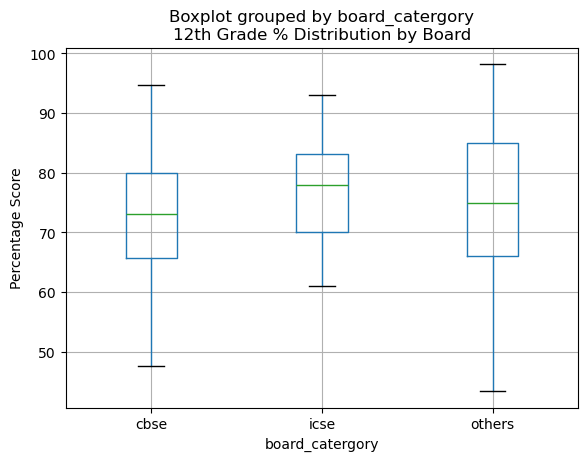

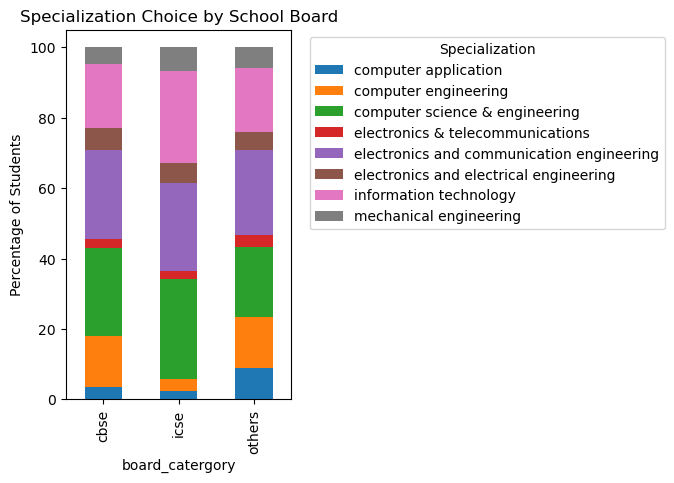

In [88]:
# Visual Analysis 

# Box plot for performance analysis
df_filtered.boxplot(column="12percentage", by="board_catergory")
py.title('12th Grade % Distribution by Board')
py.ylabel("Percentage Score")
py.show()

# 
py.subplot(1, 2, 2)
spec_board_dist = pd.crosstab(df_top['board_catergory'], df_top['Specialization'], normalize='index') * 100
spec_board_dist.plot(kind='bar', stacked=True, ax=py.gca())
py.title('Specialization Choice by School Board')
py.ylabel('Percentage of Students')
py.legend(title='Specialization', bbox_to_anchor=(1.05, 1), loc='upper left')
py.show()

# Idea 3: Personality Trait of the Top 10 Earners in Engineering
- **Main Goal:** Comparing the *top 10 highest earners in each major* by looking at the *big five common personality traits*. This can be done effectively using a **circular radar/spider chart**.

- **Data Cleanup (Transformation):**
1) **The Scale:** The personality scores are evaluated using *positive and negative numbers* from $-3$ to $+3$. If we were to use *spider charts*, it would work best with positive numbers, so we must scale them to a clean $0$ to $100$ scale. 

2) **Data Filtering:** Data grouping via **specialization** (*taking a giant, unsorted list of information and splitting it into distinct categories based on whatever "Specialization" represents in your dataset*) and take **only the top 10 rows** with the highest `salary`.    


In [109]:
# Data Cleaning

# Define Traits
personality_data = ["conscientiousness", "agreeableness", "extraversion", "nueroticism", "openess_to_experience"]

# Scalling from -3 to +3 into 0 to 100 using Min-Max
for col in personality_data:
    df[col] = ((df[col] - df[col].min())/ (df[col].max() - df[col].min())) * 100

# Groupping to find the top 10 highest earners in each specialization 
## .sortvalues("Salary", ascending=False): sorts the DataFrame so that the top row will be the highest then followed by second highest and so on
## .groupby("Specialization"): Splits into separate groups based on Specialization
## .head(10): takes the first 10 rows of each group, as it is called on a grouped object
top_earners = df.sort_values("Salary", ascending=False).groupby("Specialization").head(10)

top_earners.style

,ID,Gender,DOB,10percentage,10board,12graduation,12percentage,12board,CollegeID,CollegeTier,Degree,Specialization,collegeGPA,CollegeCityID,CollegeCityTier,CollegeState,GraduationYear,English,Logical,Quant,Domain,ComputerProgramming,ElectronicsAndSemicon,ComputerScience,MechanicalEngg,ElectricalEngg,TelecomEngg,CivilEngg,conscientiousness,agreeableness,extraversion,nueroticism,openess_to_experience,Salary
2964,41147,m,1987-09-13,53.000000,up bord,2004,61.000000,up bord,64,2,MCA,computer application,65.000000,64,0,Uttar Pradesh,2010,405,455,475,0.525923,415,-1,-1,-1,-1,-1,-1,9.160072,69.555318,52.216603,43.162372,52.393431,4000000
2295,48107,m,1987-09-09,90.830000,rbse,2005,88.770000,rbse,2857,1,B.Tech/B.E.,computer engineering,72.600000,2857,1,Rajasthan,2010,675,685,585,0.990009,655,-1,-1,-1,-1,-1,-1,53.780185,75.645296,43.632627,29.442082,80.460587,4000000
1460,325412,f,1990-08-07,76.800000,0,2009,85.360000,0,7172,2,B.Tech/B.E.,computer engineering,69.000000,7172,0,Maharashtra,2012,454,585,325,0.987207,645,-1,-1,-1,-1,-1,-1,68.872058,79.704413,62.947683,41.201401,89.230393,3500000
582,260866,m,1989-05-27,86.600000,0,2007,69.600000,0,11467,2,B.Tech/B.E.,computer engineering,72.000000,11467,0,Rajasthan,2011,675,525,525,0.600057,435,-1,-1,-1,-1,-1,-1,72.152974,87.822648,69.386035,29.442082,73.442965,2600000
1024,232481,m,1984-09-21,65.000000,icse,2003,63.000000,isc,81,2,B.Tech/B.E.,electronics and electrical engineering,63.300000,81,0,Uttar Pradesh,2011,575,475,605,-1.000000,315,-1,-1,-1,-1,-1,-1,77.402099,85.793089,73.678763,41.202569,69.935265,2500000
2244,281074,m,1989-06-11,84.670000,andhra pradesh state board,2007,77.100000,andhra pradesh state board,3144,2,B.Tech/B.E.,electronics & instrumentation eng,76.500000,3144,1,Tamil Nadu,2011,545,675,655,0.910770,405,433,-1,-1,-1,-1,-1,48.531060,97.970441,86.555467,52.961388,94.493610,2300000
1307,345175,m,1987-10-13,79.160000,0,2004,77.400000,0,55,2,B.Tech/B.E.,computer engineering,62.400000,55,0,Uttar Pradesh,2010,505,635,525,0.765674,485,-1,-1,-1,-1,-1,-1,30.156574,77.167465,80.117115,41.201401,71.689670,2000000
443,1045685,m,1993-03-18,90.000000,cbse,2010,89.400000,cbse,13594,1,B.Tech/B.E.,computer science & engineering,83.700000,13594,0,Uttar Pradesh,2014,560,555,585,0.842248,505,-1,469,-1,-1,-1,-1,90.243861,97.477363,70.455150,12.686181,76.595343,2000000
198,803778,m,1992-04-24,69.500000,state board,2008,68.500000,state board,7770,2,B.Tech/B.E.,information technology,69.900000,7770,0,Madhya Pradesh,2013,475,500,235,0.413838,385,-1,-1,-1,-1,-1,-1,75.610502,88.812708,86.364712,50.746393,93.617517,2000000
2249,1254777,f,1993-10-05,81.300000,cbse,2010,77.000000,cbse,1615,2,B.Tech/B.E.,computer science & engineering,79.900000,1615,0,Punjab,2015,465,425,270,0.744758,415,-1,438,-1,-1,-1,-1,63.415752,88.812708,75.000739,29.602202,89.361419,1800000


**Statistical Analysis** : 
+ To identify if certain traits are more rigid among high earners in a specific field, we can calculate the **mean** and **standard deviation** for each top 5 traits specifically for the **top 10 earners within each specialization**. 
+ We can determine the **mode** or basically the **highest-ranking trait** for the top earners in each branch to determine the dominant trait that top earners has in specific specialization .

**Visual Analysis**:
+ To visually represent the "psychological shape" of success for that branch, we will generate a **circular radar chart** for the average top 10 earners in major specializations.
+ For deeper insight, we can overlay two spider charts on the same axes for example Top 10 CS vs Top 10 Mechanical Engineering to find out where the profile differ for both these specializations. 
+ For a quick visual comparison across many engineering branches simulataneously to find trends and patterns, we can create a **heatmap** where the Y-axis is the specialization and X-axis the personality trait. Meanwhile, the intensity of the color will represent the average score of the top 10 earners.

**Observations**:
+ From the analysis we can then find out whether specific engineering roles might demand certain personality and if one would like to be a top earner in a major specialization, what personality does he/she needs. 


In [114]:
# Statstical Analysis

# Mean and standard deviation per Specialization for top 5 traits of top earners with each specialization
print(top_earners.groupby("Specialization")[personality_data].agg(['mean','std']))

                                            conscientiousness             \
                                                         mean        std   
Specialization                                                             
aeronautical engineering                            56.889017  12.046640   
applied electronics and instrumentation             76.097884  17.537056   
automobile/automotive engineering                   64.757328   8.908554   
biomedical engineering                              65.591142  24.126600   
biotechnology                                       70.399076  16.738202   
ceramic engineering                                 75.610502        NaN   
chemical engineering                                56.492690  20.446786   
civil engineering                                   58.933023  17.716757   
computer and communication engineering              70.731583        NaN   
computer application                                66.350915  21.877642   
computer eng

In [117]:
# Dominant trait that top earners has in specific specialization by using mode
## To do this we first sort them by specialization and only looking at the personality_data, calculate the mean for each trait within each 
## specialization, then using .idxmax() find the highest mean value for each specialization.
##  .idxmax(axis=1): axis=1 means horizontally across columns which is specialization, find the highest number
dominant_traits = top_earners.groupby('Specialization')[personality_data].mean().idxmax(axis=1)
print("\nDominant Personality Trait per Specialization:\n", dominant_traits)


Dominant Personality Trait per Specialization:
 Specialization
aeronautical engineering                       openess_to_experience
applied electronics and instrumentation                agreeableness
automobile/automotive engineering                      agreeableness
biomedical engineering                         openess_to_experience
biotechnology                                  openess_to_experience
ceramic engineering                            openess_to_experience
chemical engineering                           openess_to_experience
civil engineering                              openess_to_experience
computer and communication engineering                  extraversion
computer application                           openess_to_experience
computer engineering                                   agreeableness
computer networking                                    agreeableness
computer science & engineering                 openess_to_experience
computer science and technology        

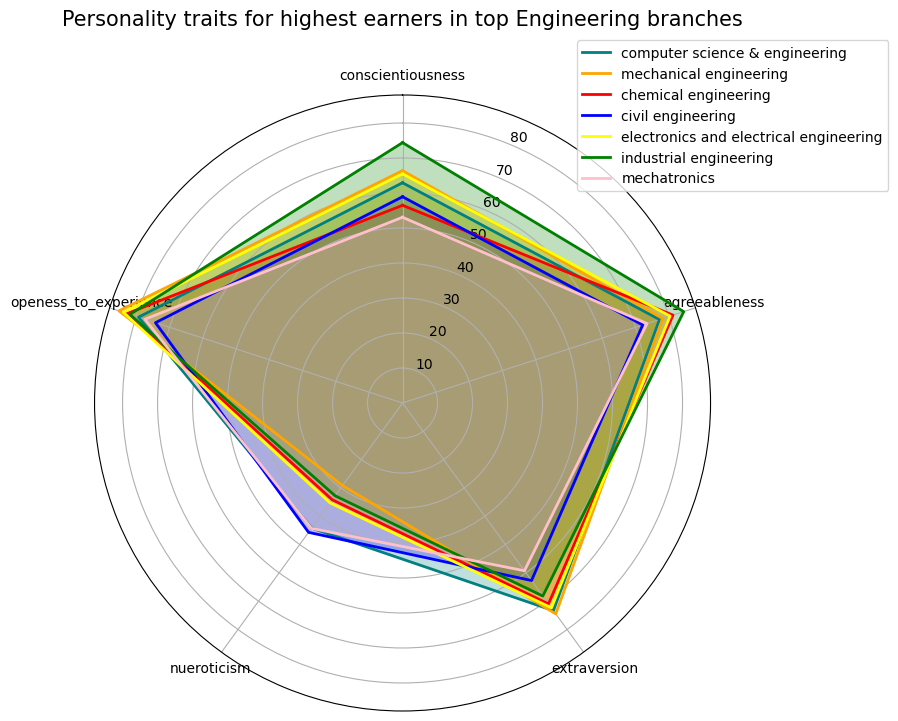

In [123]:
# Visual Analysis 

# Radar/Spider Charts 
def plot_radar(specializations_to_plot, title, colors):
    categories = personality_data
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = py.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    for i, spec in enumerate(specializations_to_plot):
        values = top_earners[top_earners['Specialization'] == spec][personality_data].mean().values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, color=colors[i], linewidth=2, label=spec)
        ax.fill(angles, values, color=colors[i], alpha=0.25)
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    py.xticks(angles[:-1], categories)
    py.title(title, size=15, y=1.1)
    py.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    py.show()

plot_radar(['computer science & engineering', 'mechanical engineering', 'chemical engineering', 'civil engineering', 
            'electronics and electrical engineering', 'industrial engineering', 'mechatronics' ], 
           "Personality traits for highest earners in top Engineering branches", ['teal', 'orange', 'red', 'blue', 'yellow', 'green', 'pink'])

**Process to draw a radar/spider chart:**
1) Radar chart displays multiple variables radiating out from a central poin, so we must divide a full circle by the number of categories we have.
2) Standard plots use regular grids, but for spider charts we have to tell Matplotlib to use polar projection.
3) For each specialization we would like to compare, we need to grab the average personity scores.
4) After we have the angles mapped out and the values assigned to them, we can then draw the lines and fill the inner area with a transparent colour.
5) By default, the plotting angles starts from right hand side (3o'clock) and moves counter-clockwise, so to make it look much cleaner, we start at the top (12o'clock) and move clockwise.
6) To trigger the function, we just need to pass the parameters into the function of `plot_radar`. 

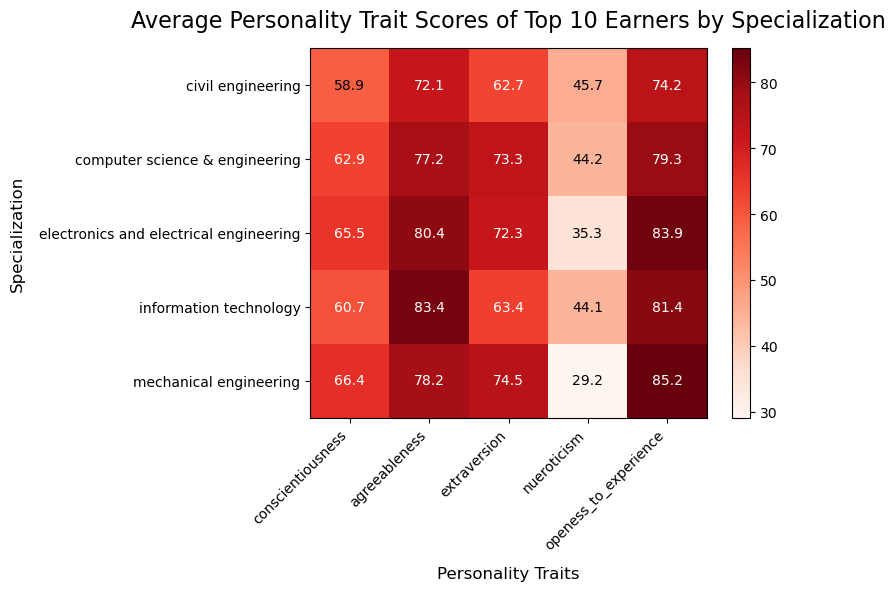

In [147]:
# Heatmap of Traits 
heatmap_data = top_earners.groupby('Specialization')[personality_data].mean()
heatmap_data

## Showing only specialization that has more than 10 occurance so data is more accurate
spec_counts = df['Specialization'].value_counts()
major_specs = spec_counts[spec_counts >= 10].index
heatmap_data = heatmap_data[heatmap_data.index.isin(major_specs)]

## Can remove this line if want to show the rest
spec_to_keep = ["civil engineering", "computer science & engineering", "electronics and electrical engineering", 
                "information technology", "mechanical engineering"]
for spec in spec_to_keep:
    heatmap_data = heatmap_data.loc[spec_to_keep]

## Plotting
py.figure()
im = py.imshow(heatmap_data.values, cmap='Reds', aspect='auto')
py.colorbar(im)
py.xticks(np.arange(len(heatmap_data.columns)), heatmap_data.columns, rotation=45, ha='right')
py.yticks(np.arange(len(heatmap_data.index)), heatmap_data.index)

## Value labelling on each boxes for better analysis 
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        color = "white" if val > heatmap_data.values.max() * 0.7 else "black"
        py.text(j, i, f"{val:.1f}", ha="center", va="center", color=color)   

py.title("Average Personality Trait Scores of Top 10 Earners by Specialization",size=16, pad=15)
py.xlabel('Personality Traits', size=12, labelpad=10)
py.ylabel('Specialization', size=12, labelpad=10)

py.show()